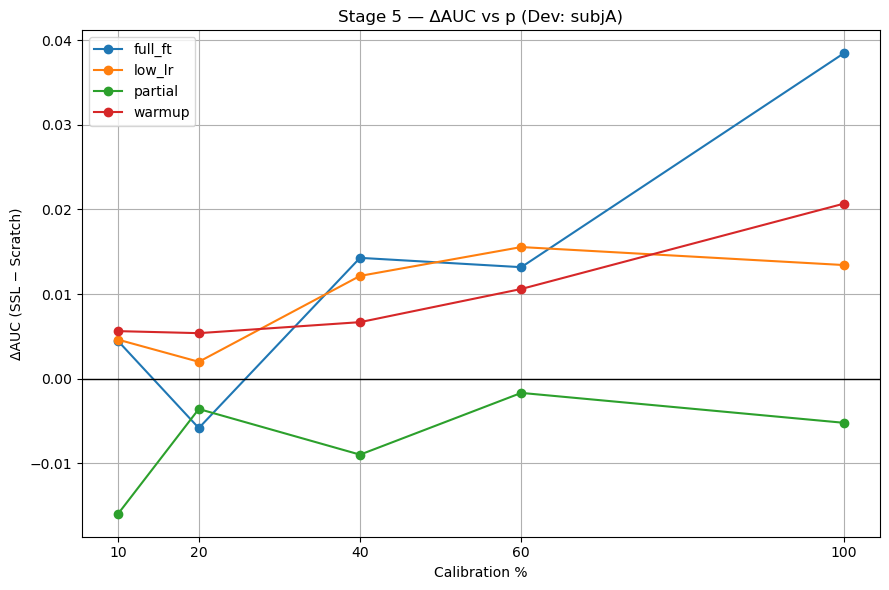

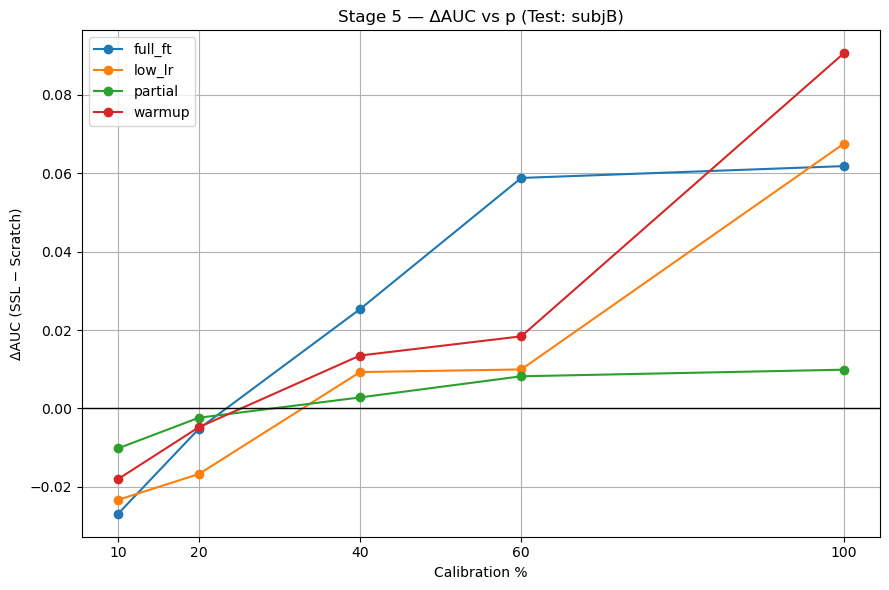

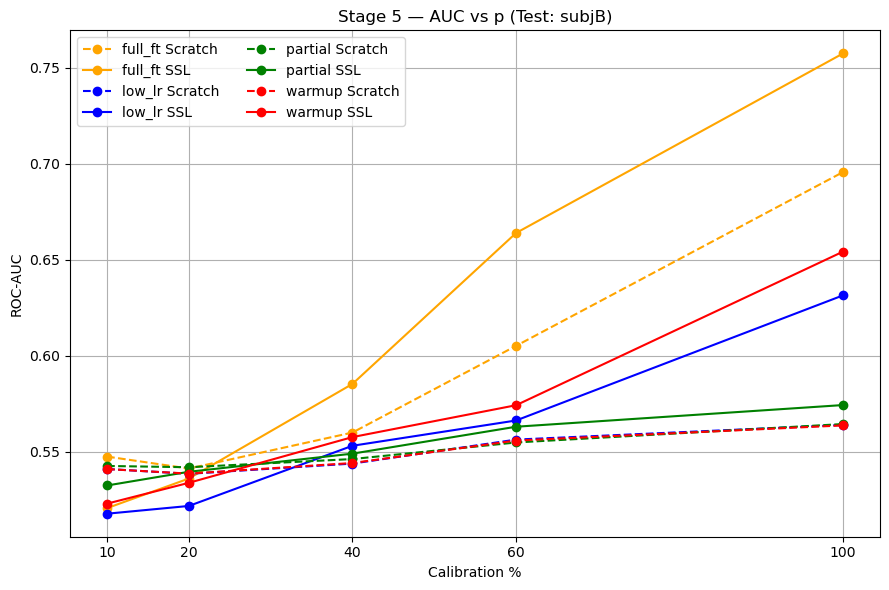

Saved:
 - C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02\stage5_all_scenarios_long.csv
 - C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02\stage5_scenarios_ranking.csv
 - C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02\stage5_dev_summary.csv
 - C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02\stage5_test_summary.csv
 - plots in: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02

=== Ranking (higher is better) ===


,scenario,mean_delta_low,mean_delta_mid,delta_100,mean_ssl_low,mean_scr_low,subject,test_mean_delta_low,test_mean_delta_mid,test_delta_100,score_dev,score_total
0,full_ft,-0.000717,0.013727,0.038472,0.537886,0.538602,subjA,-0.016017,0.042046,0.061784,0.056913,0.040897
1,warmup,0.005491,0.008634,0.020687,0.535976,0.530485,subjA,-0.011390,0.015942,0.090535,0.050111,0.038721
2,low_lr,0.003291,0.013850,0.013429,0.533758,0.530467,subjA,-0.020014,0.009611,0.067488,0.044077,0.024063
3,partial,-0.009795,-0.005350,-0.005233,0.521992,0.531788,subjA,-0.006264,0.005508,0.009886,-0.042643,-0.048907



=== Dev summary ===


,scenario,mean_delta_low,mean_delta_mid,delta_100,mean_ssl_low,mean_scr_low,subject
0,full_ft,-0.000717,0.013727,0.038472,0.537886,0.538602,subjA
1,low_lr,0.003291,0.013850,0.013429,0.533758,0.530467,subjA
2,partial,-0.009795,-0.005350,-0.005233,0.521992,0.531788,subjA
3,warmup,0.005491,0.008634,0.020687,0.535976,0.530485,subjA



=== Test summary ===


,scenario,mean_delta_low,mean_delta_mid,delta_100,mean_ssl_low,mean_scr_low,subject
0,full_ft,-0.016017,0.042046,0.061784,0.528446,0.544463,subjB
1,low_lr,-0.020014,0.009611,0.067488,0.519851,0.539865,subjB
2,partial,-0.006264,0.005508,0.009886,0.536096,0.542360,subjB
3,warmup,-0.011390,0.015942,0.090535,0.528498,0.539888,subjB


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) INPUT: paths on Windows
# =========================
SCENARIO_FILES = {
    "full_ft": r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\full_ft\stage5_full_ft_results_v2.csv",
    "low_lr": r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\low_lr_encoder\stage5_ft_low_lr_encoder_v1_results.csv",
    "warmup": r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\ft_head_warmup_low_lr\stage5_ft_head_warmup_low_lr_v1_results.csv",
    "partial": r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\ft_partial_down4\stage5_ft_partial_down4_v1_results.csv",
}

OUT_DIR = r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary_02"

DEV_SUBJECT = "subjA"   # Dev
TEST_SUBJECT = "subjB"  # Test

P_LIST = [10, 20, 40, 60, 100]
LOW_P = [10, 20]
MID_P = [40, 60]
HIGH_P = [100]

# =========================
# 2) Load + unify
# =========================
def load_one(path: str, scenario: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"subject", "p", "scratch_auc", "ssl_auc"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{scenario}: missing columns {missing} in file:\n{path}")

    df = df.copy()
    df["scenario"] = scenario
    df["p"] = df["p"].astype(int)
    df["delta_auc"] = df["ssl_auc"] - df["scratch_auc"]
    return df[["scenario", "subject", "p", "scratch_auc", "ssl_auc", "delta_auc"]]

all_df = pd.concat(
    [load_one(path, scen) for scen, path in SCENARIO_FILES.items()],
    ignore_index=True
).sort_values(["scenario", "subject", "p"]).reset_index(drop=True)

# sanity: ensure all p exist
for scen in all_df["scenario"].unique():
    for subj in all_df["subject"].unique():
        ps = sorted(all_df[(all_df["scenario"]==scen) & (all_df["subject"]==subj)]["p"].unique().tolist())
        if ps and ps != P_LIST:
            print(f"[WARN] {scen} {subj}: p_list mismatch: {ps}")

# =========================
# 3) Summaries + ranking
# =========================
def scenario_summary(df: pd.DataFrame, subject: str) -> pd.DataFrame:
    d = df[df["subject"] == subject].copy()

    def mean_on(p_set, col):
        return lambda s: d.loc[s.index, col][d.loc[s.index, "p"].isin(p_set)].mean()

    out = (d.groupby("scenario")
             .agg(
                 mean_delta_low=("delta_auc", lambda s: d.loc[s.index, "delta_auc"][d.loc[s.index, "p"].isin(LOW_P)].mean()),
                 mean_delta_mid=("delta_auc", lambda s: d.loc[s.index, "delta_auc"][d.loc[s.index, "p"].isin(MID_P)].mean()),
                 delta_100=("delta_auc", lambda s: d.loc[s.index, "delta_auc"][d.loc[s.index, "p"].isin(HIGH_P)].mean()),
                 mean_ssl_low=("ssl_auc", lambda s: d.loc[s.index, "ssl_auc"][d.loc[s.index, "p"].isin(LOW_P)].mean()),
                 mean_scr_low=("scratch_auc", lambda s: d.loc[s.index, "scratch_auc"][d.loc[s.index, "p"].isin(LOW_P)].mean()),
             )
             .reset_index())
    out["subject_role"] = subject
    return out

dev_sum = scenario_summary(all_df, DEV_SUBJECT).rename(columns={"subject_role":"subject"})
test_sum = scenario_summary(all_df, TEST_SUBJECT).rename(columns={"subject_role":"subject"})

rank_df = dev_sum.merge(
    test_sum[["scenario", "mean_delta_low", "mean_delta_mid", "delta_100"]].rename(columns={
        "mean_delta_low":"test_mean_delta_low",
        "mean_delta_mid":"test_mean_delta_mid",
        "delta_100":"test_delta_100"
    }),
    on="scenario",
    how="left"
)

# Conference-oriented scoring: prioritize low-calibration on Dev, then mid, then 100.
rank_df["score_dev"] = (
      3.0 * rank_df["mean_delta_low"].fillna(0)
    + 1.5 * rank_df["mean_delta_mid"].fillna(0)
    + 1.0 * rank_df["delta_100"].fillna(0)
)

# Mild sanity bonus from Test (if available)
rank_df["score_total"] = rank_df["score_dev"] + 1.0 * rank_df["test_mean_delta_low"].fillna(0)

rank_df = rank_df.sort_values("score_total", ascending=False).reset_index(drop=True)

# =========================
# 4) Plots
# =========================
def plot_delta(df: pd.DataFrame, subject: str, out_path: str, title: str):
    d = df[df["subject"] == subject].copy()
    plt.figure(figsize=(9,6))
    for scen in sorted(d["scenario"].unique()):
        dd = d[d["scenario"] == scen].sort_values("p")
        plt.plot(dd["p"], dd["delta_auc"], marker="o", linestyle="-", label=scen)
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(P_LIST)
    plt.xlabel("Calibration %")
    plt.ylabel("ΔAUC (SSL − Scratch)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

def plot_auc(df: pd.DataFrame, subject: str, out_path: str, title: str):
    d = df[df["subject"] == subject].copy()
    plt.figure(figsize=(9,6))
    colors = ['orange', 'blue', 'green', 'red']
    i = -1
    for scen in sorted(d["scenario"].unique()):
        i += 1
        dd = d[d["scenario"] == scen].sort_values("p")
        plt.plot(dd["p"], dd["scratch_auc"], marker="o", color = colors[i], linestyle="--", label=f"{scen} Scratch")
        plt.plot(dd["p"], dd["ssl_auc"], marker="o", color = colors[i], linestyle="-", label=f"{scen} SSL")
    plt.xticks(P_LIST)
    plt.xlabel("Calibration %")
    plt.ylabel("ROC-AUC")
    plt.title(title)
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

# =========================
# 5) Save outputs
# =========================
import os
os.makedirs(OUT_DIR, exist_ok=True)

all_df_path = os.path.join(OUT_DIR, "stage5_all_scenarios_long.csv")
rank_path = os.path.join(OUT_DIR, "stage5_scenarios_ranking.csv")
dev_sum_path = os.path.join(OUT_DIR, "stage5_dev_summary.csv")
test_sum_path = os.path.join(OUT_DIR, "stage5_test_summary.csv")

all_df.to_csv(all_df_path, index=False)
rank_df.to_csv(rank_path, index=False)
dev_sum.to_csv(dev_sum_path, index=False)
test_sum.to_csv(test_sum_path, index=False)

plot_delta(all_df, DEV_SUBJECT,
           os.path.join(OUT_DIR, "delta_auc_compare_scenarios_dev_subjA.png"),
           f"Stage 5 — ΔAUC vs p (Dev: {DEV_SUBJECT})")

plot_delta(all_df, TEST_SUBJECT,
           os.path.join(OUT_DIR, "delta_auc_compare_scenarios_test_subjB.png"),
           f"Stage 5 — ΔAUC vs p (Test: {TEST_SUBJECT})")

plot_auc(all_df, TEST_SUBJECT,
         os.path.join(OUT_DIR, "auc_compare_scenarios_test_subjB.png"),
         f"Stage 5 — AUC vs p (Test: {TEST_SUBJECT})")

print("Saved:")
print(" -", all_df_path)
print(" -", rank_path)
print(" -", dev_sum_path)
print(" -", test_sum_path)
print(" - plots in:", OUT_DIR)

print("\n=== Ranking (higher is better) ===")
display(rank_df)

print("\n=== Dev summary ===")
display(dev_sum.sort_values("scenario"))

print("\n=== Test summary ===")
display(test_sum.sort_values("scenario"))

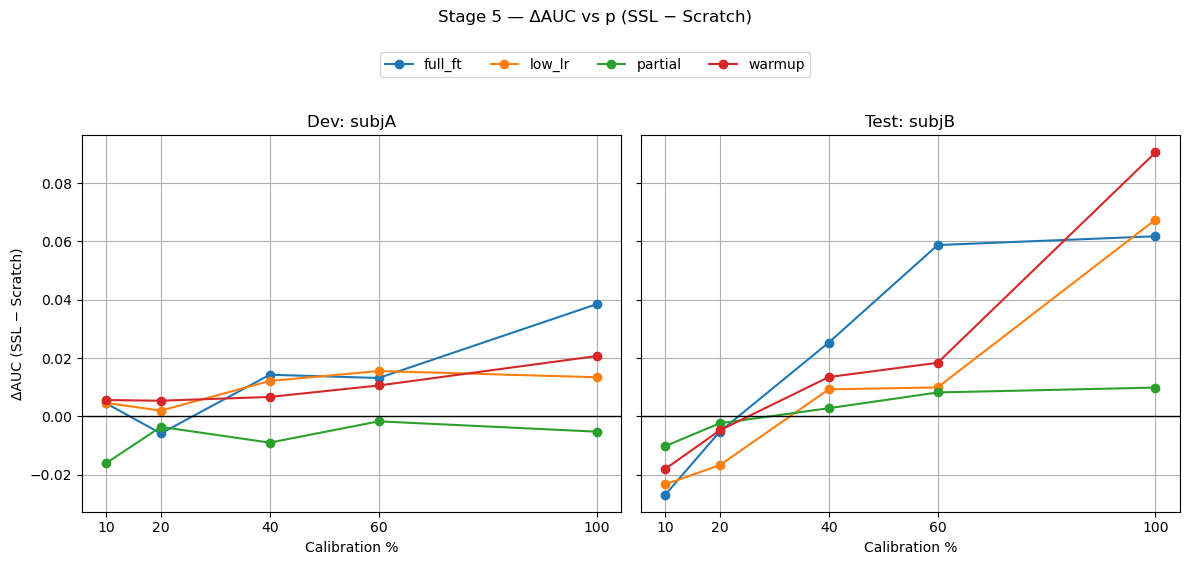

Saved: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\delta_auc_dev_test_two_panel.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Если all_df уже есть — пропусти загрузку.
# Иначе раскомментируй и укажи путь к объединённому CSV (который мы сохраняли).
# all_df = pd.read_csv(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\stage5_all_scenarios_long.csv")

DEV_SUBJECT = "subjA"
TEST_SUBJECT = "subjB"
P_LIST = [10, 20, 40, 60, 100]

# Если в all_df нет delta_auc, посчитаем
if "delta_auc" not in all_df.columns:
    all_df = all_df.copy()
    all_df["delta_auc"] = all_df["ssl_auc"] - all_df["scratch_auc"]

def plot_two_panel_delta_auc(all_df, dev_subject="subjA", test_subject="subjB", scenarios=None):
    df = all_df.copy()
    df["p"] = df["p"].astype(int)

    if scenarios is None:
        scenarios = sorted(df["scenario"].unique().tolist())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # --- Left: Dev ---
    ax = axes[0]
    d_dev = df[df["subject"] == dev_subject]
    for scen in scenarios:
        dd = d_dev[d_dev["scenario"] == scen].sort_values("p")
        if dd.empty:
            continue
        ax.plot(dd["p"], dd["delta_auc"], marker="o", linestyle="-", label=scen)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Dev: {dev_subject}")
    ax.set_xlabel("Calibration %")
    ax.set_ylabel("ΔAUC (SSL − Scratch)")
    ax.set_xticks(P_LIST)
    ax.grid(True)

    # --- Right: Test ---
    ax = axes[1]
    d_test = df[df["subject"] == test_subject]
    for scen in scenarios:
        dd = d_test[d_test["scenario"] == scen].sort_values("p")
        if dd.empty:
            continue
        ax.plot(dd["p"], dd["delta_auc"], marker="o", linestyle="-", label=scen)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Test: {test_subject}")
    ax.set_xlabel("Calibration %")
    ax.set_xticks(P_LIST)
    ax.grid(True)

    # Общая легенда (снаружи)
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(scenarios), bbox_to_anchor=(0.5, 1.05))

    fig.suptitle("Stage 5 — ΔAUC vs p (SSL − Scratch)", y=1.12)
    fig.tight_layout()

    return fig

fig = plot_two_panel_delta_auc(all_df, DEV_SUBJECT, TEST_SUBJECT)

# Сохранение (ВАЖНО: savefig ДО show, чтобы не получить белый лист)
out_path = r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\delta_auc_dev_test_two_panel.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", out_path)

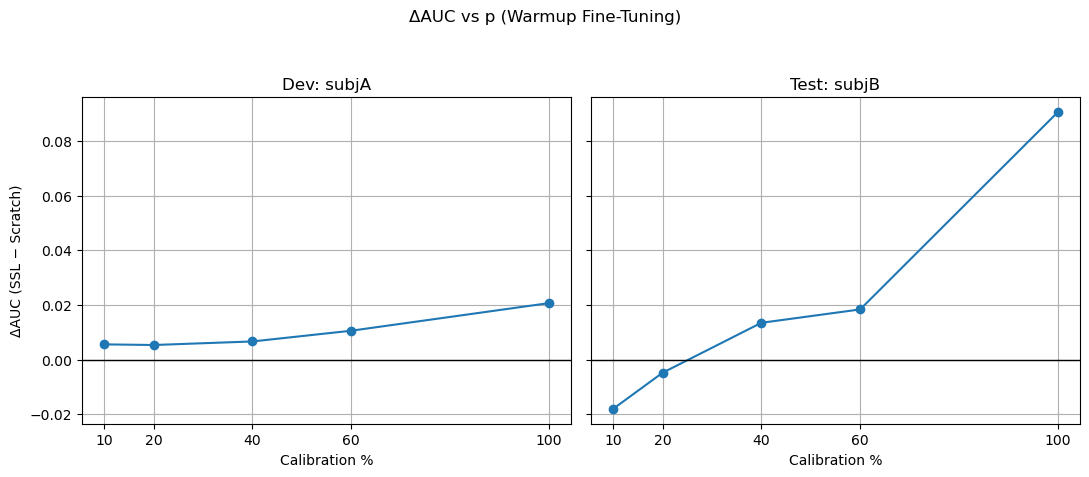

Saved: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\delta_auc_dev_test_warmup.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Если all_df уже есть в памяти — пропусти загрузку.
# Иначе укажи путь к объединённому CSV:
# all_df = pd.read_csv(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\stage5_all_scenarios_long.csv")

DEV_SUBJECT = "subjA"
TEST_SUBJECT = "subjB"
SCENARIO = "warmup"          # финальный выбранный сценарий
P_LIST = [10, 20, 40, 60, 100]

# Если delta_auc нет — посчитаем
if "delta_auc" not in all_df.columns:
    all_df = all_df.copy()
    all_df["delta_auc"] = all_df["ssl_auc"] - all_df["scratch_auc"]

df = all_df.copy()
df["p"] = df["p"].astype(int)

# Фильтруем только выбранный сценарий
df = df[df["scenario"] == SCENARIO]

# --- Two-panel plot: Dev (left) + Test (right) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

# Left: Dev
ax = axes[0]
d_dev = df[df["subject"] == DEV_SUBJECT].sort_values("p")
ax.plot(d_dev["p"], d_dev["delta_auc"], marker="o", linestyle="-")
ax.axhline(0, color="black", linewidth=1)
ax.set_title(f"Dev: {DEV_SUBJECT}")
ax.set_xlabel("Calibration %")
ax.set_ylabel("ΔAUC (SSL − Scratch)")
ax.set_xticks(P_LIST)
ax.grid(True)

# Right: Test
ax = axes[1]
d_test = df[df["subject"] == TEST_SUBJECT].sort_values("p")
ax.plot(d_test["p"], d_test["delta_auc"], marker="o", linestyle="-")
ax.axhline(0, color="black", linewidth=1)
ax.set_title(f"Test: {TEST_SUBJECT}")
ax.set_xlabel("Calibration %")
ax.set_xticks(P_LIST)
ax.grid(True)

fig.suptitle("ΔAUC vs p (Warmup Fine-Tuning)", y=1.05)
fig.tight_layout()

# Сохраняем (savefig ДО show — иначе можно получить белый лист)
out_path = r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning к конференции\_summary\delta_auc_dev_test_warmup.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_path)